Importing Dataset & Viewing Data

In [ ]:
import sqlite3
import pandas as pd

# Connect to database
conn = sqlite3.connect("gas_monitoring.db")

# Read sample data
df = pd.read_sql_query("SELECT * FROM gas_monitoring;", conn)


# EDA

In [ ]:
# describe data
df.describe()

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID
count,10000.000000,8072.000000,10000.000000,10000.000000,10000.000000,8590.000000,10000.000000,10000.000000,9166.000000,10000.000000
mean,42.243124,51.643609,109.864352,578.634082,470.932316,728.354408,680.488646,612.247715,1.288239,5427.921400
std,73.974956,21.333894,33.793851,22.573537,51.459025,29.140123,55.953530,43.174354,0.779754,2590.836924
min,6.903485,-49.870000,-17.472184,408.599386,286.825662,611.168916,456.673900,412.791904,0.000000,1374.000000
25%,18.937500,47.660000,96.660377,559.353100,440.035413,709.660122,658.519775,585.511731,1.000000,3074.000000
50%,20.510000,51.390000,112.807103,579.361082,469.146955,726.748925,679.908353,609.526245,1.000000,5214.000000
75%,23.172500,53.840000,124.540226,595.569759,494.770045,744.879789,703.522845,636.012105,2.000000,7395.000000
max,307.070000,198.900000,237.873938,637.895790,632.891693,807.732943,906.213097,736.112361,4.000000,9658.000000


In [ ]:
# sumemrise data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

In [ ]:
print("\nCounts for 'Session ID':")
print(df['Session ID'].value_counts(dropna=False))


Counts for 'Session ID':
Session ID
6528    388
4703    387
3418    368
1374    362
5820    357
7058    350
3592    345
2105    341
2847    335
3856    335
7395    312
8936    309
1903    306
4507    301
1826    284
9385    280
2679    275
9658    266
4129    257
5693    255
9127    247
6431    245
7241    242
9184    241
8052    241
3074    235
9241    234
7963    232
8374    214
6817    198
5172    196
4761    178
1458    177
6847    175
5214    171
1482    161
8649    144
2586     56
Name: count, dtype: int64


## Histogram for Individual Columns

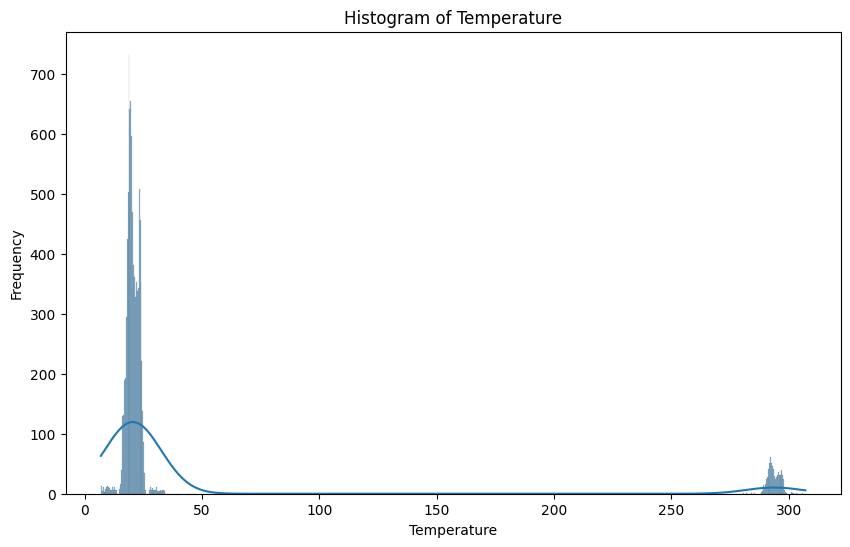

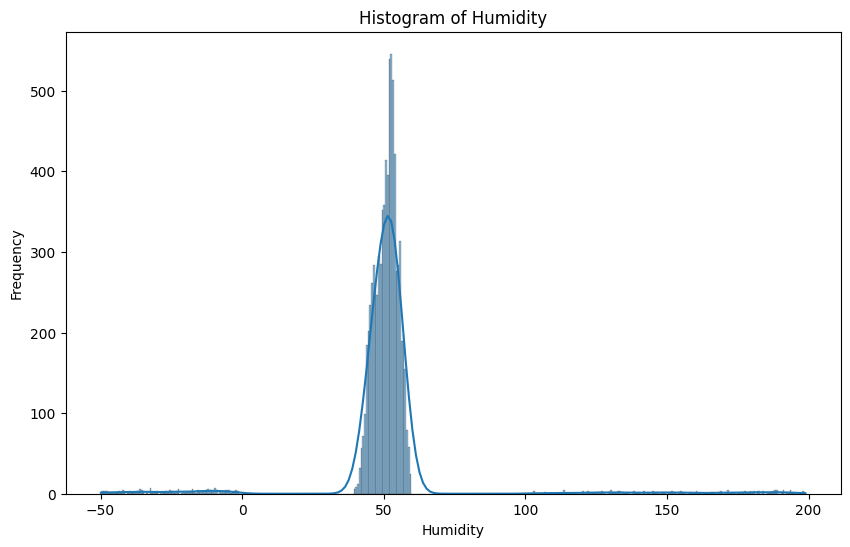

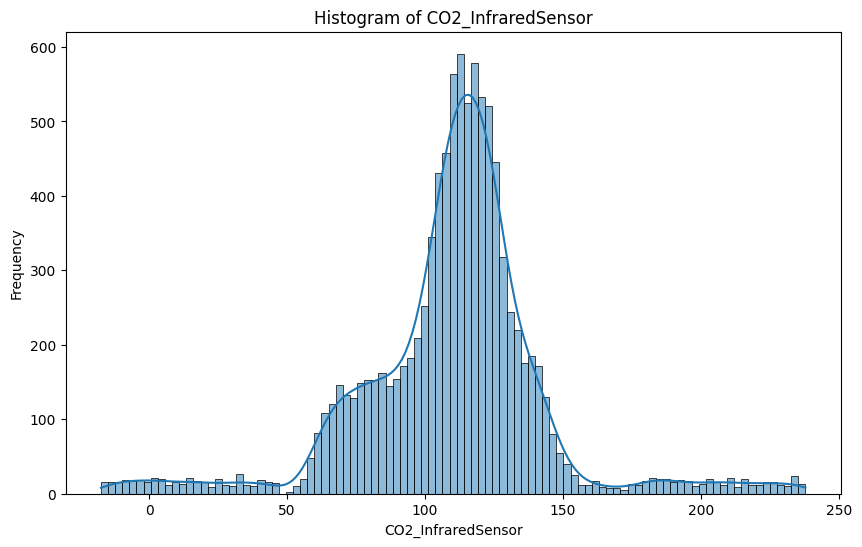

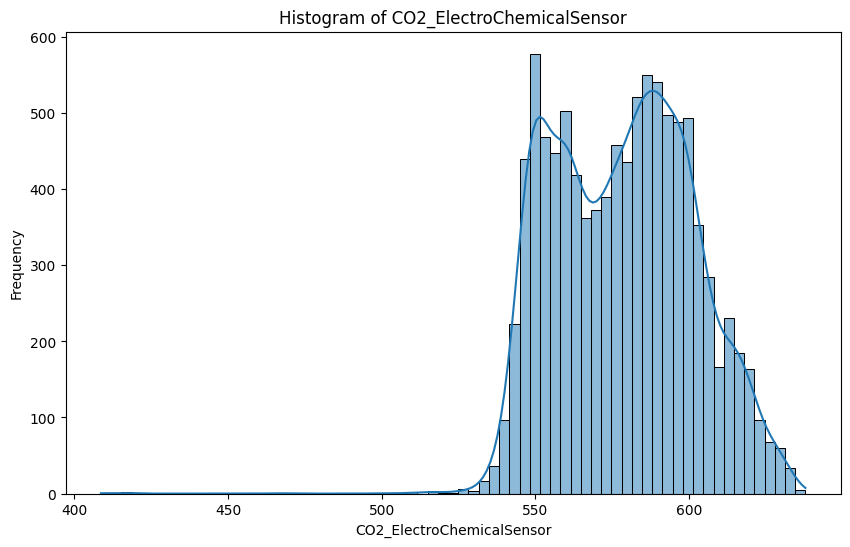

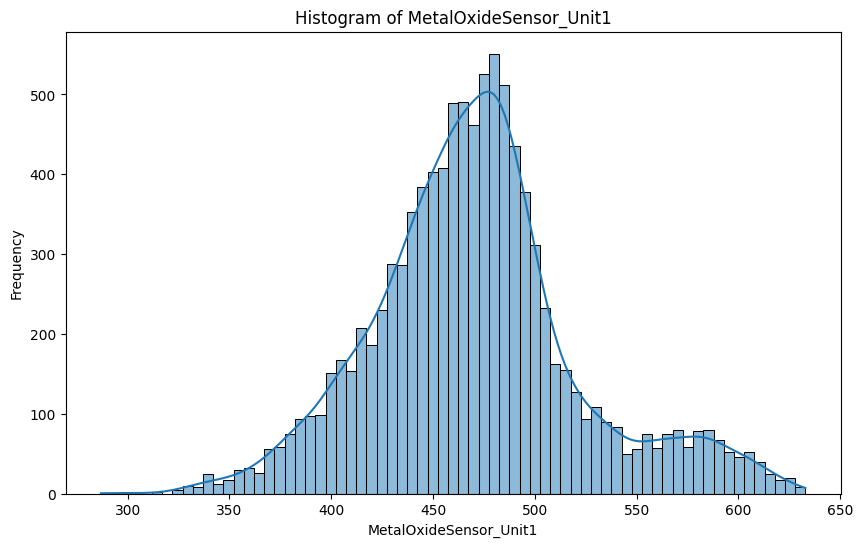

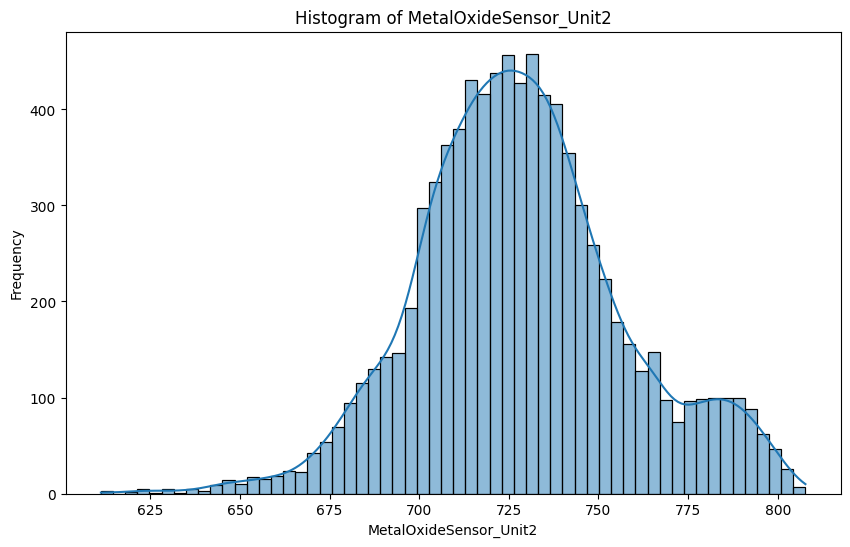

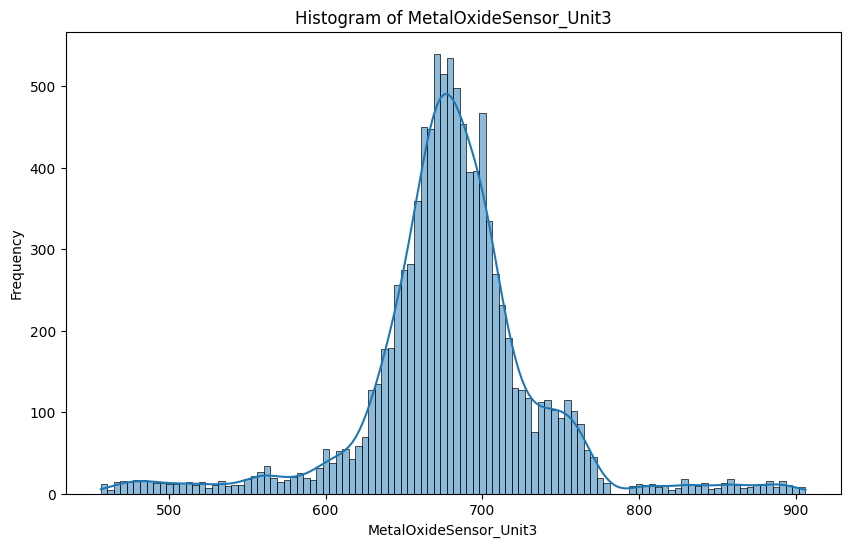

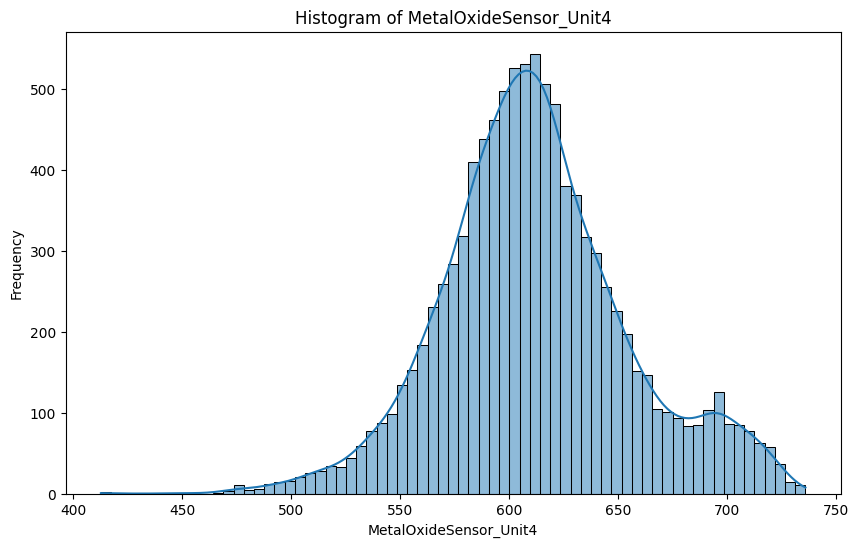

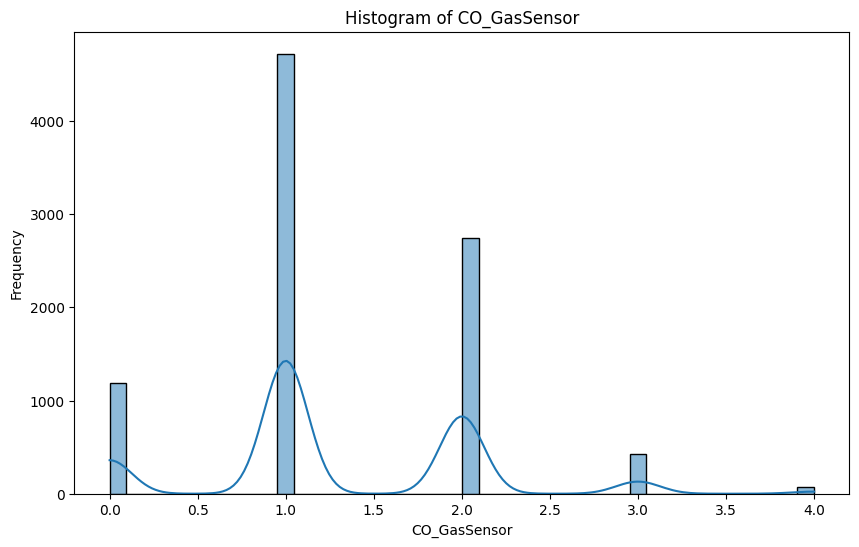

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for histograms
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Remove 'Session ID' if it's still present and not relevant for distribution analysis
if 'Session ID' in numeric_cols:
    numeric_cols = numeric_cols.drop('Session ID')

# Generate histograms for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Observation (Numbers provided are estimates)

Temperature
- contains a cluster data of extreme temperatures at 280 degrees Celsius
- most data clusters at 25 degrees

Humidity
- most data clusters at 50% humidity
- abnormal data ranges from -50% to 0% and 100% to 200%

CO2
- most data clusters at 120 and some at 75


Class Counts for Categorical Labels

In [ ]:
print("Class Counts for 'Time of Day':")
print(df['Time of Day'].value_counts())

print("\nClass Counts for 'HVAC Operation Mode':")
print(df['HVAC Operation Mode'].value_counts())

print("\nClass Counts for 'Ambient Light Level':")
print(df['Ambient Light Level'].value_counts())

print("\nClass Counts for 'Activity Level':")
print(df['Activity Level'].value_counts())

print("\nClass Counts for 'CO_GasSensor':")
print(df['CO_GasSensor'].value_counts(dropna=False))

Class Counts for 'Time of Day':
Time of Day
afternoon    2635
evening      2476
morning      2460
night        2429
Name: count, dtype: int64

Class Counts for 'HVAC Operation Mode':
HVAC Operation Mode
cooling_active      1502
maintenance_mode    1500
heating_active      1468
off                 1456
eco_mode            1452
ventilation_only    1394
COOLING_ACTIVE       112
ECO_MODE             112
MAINTENANCE_MODE     106
Off                  103
VENTILATION_ONLY      98
HEATING_ACTIVE        98
OFF                   93
Cooling_Active        64
Eco_mode              56
Eco_Mode              53
Heating_active        50
Cooling_active        50
Maintenance_Mode      49
Maintenance_mode      48
Ventilation_Only      47
Ventilation_only      45
Heating_Active        44
Name: count, dtype: int64

Class Counts for 'Ambient Light Level':
Ambient Light Level
very_bright    3387
bright         2697
moderate       1463
dim             864
very_dim        535
Name: count, dtype: int64

Class Co

Activity Level
- Low has significantly higher amounts, followed by

Heat Map Correlation

### Pearson Correlation of Features with Ordinally Encoded Activity Level

This heatmap shows the Pearson correlation coefficients between the environmental and gas sensor features and the 'Activity Level' column, which has been ordinally encoded. This provides a direct measure of the linear relationship between numerical features and the activity level, treated as an ordered categorical variable.

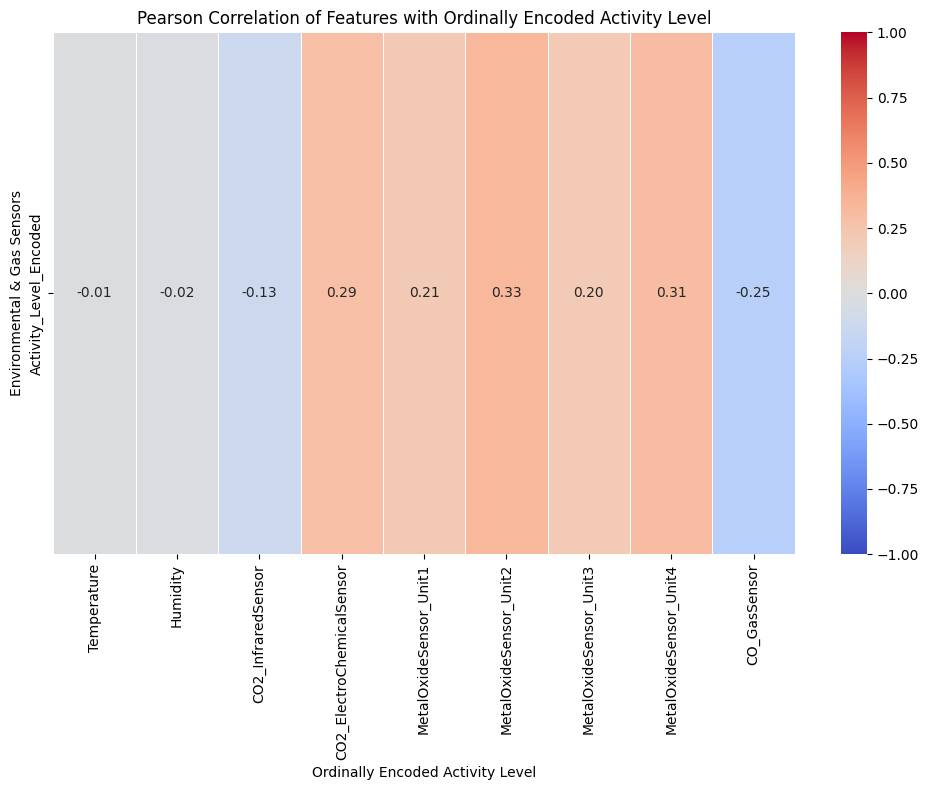

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy to perform transformations
dfv_ordinal_activity = df.copy()

# Drop 'Session ID' as it's not relevant for correlation analysis
dfv_ordinal_activity = dfv_ordinal_activity.drop('Session ID', axis=1)

# Apply data uniformity changes for 'Activity Level' and 'HVAC Operation Mode'
# Standardize 'Activity Level' categories
dfv_ordinal_activity['Activity Level'] = dfv_ordinal_activity['Activity Level'].replace({
    'LowActivity': 'Low Activity',
    'ModerateActivity': 'Moderate Activity'
})

# Ordinally encode 'Activity Level'
activity_mapping = {'Low Activity': 0, 'Moderate Activity': 1, 'High Activity': 2}
dfv_ordinal_activity['Activity_Level_Encoded'] = dfv_ordinal_activity['Activity Level'].map(activity_mapping)

# Drop the original 'Activity Level' column
dfv_ordinal_activity = dfv_ordinal_activity.drop('Activity Level', axis=1)

# Select only numeric columns for Pearson correlation
numeric_df_ordinal = dfv_ordinal_activity.select_dtypes(include=["number"])

# Calculate the Pearson correlation matrix
corr_matrix_ordinal = numeric_df_ordinal.corr(method="pearson")

# Extract correlations with the new 'Activity_Level_Encoded' column
activity_level_corr = corr_matrix_ordinal[['Activity_Level_Encoded']].drop('Activity_Level_Encoded', axis=0)

# Plot the heatmap focused on Activity_Level_Encoded as the Y-axis
plt.figure(figsize=(10, 8))
sns.heatmap(
    activity_level_corr.T, # Transpose to have features on Y-axis and Activity Level on X-axis
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation of Features with Ordinally Encoded Activity Level")
plt.xlabel("Ordinally Encoded Activity Level")
plt.ylabel("Environmental & Gas Sensors")
plt.tight_layout()
plt.show()

### Pearson Correlation of All Features with Ordinally Encoded Activity Level (Including Encoded Categoricals)

This heatmap now shows the Pearson correlation coefficients between all environmental and gas sensor features, as well as the ordinally encoded 'Ambient Light Level' and 'Time of Day', with the ordinally encoded 'Activity Level'. This gives a comprehensive view of how all these factors linearly relate to activity.

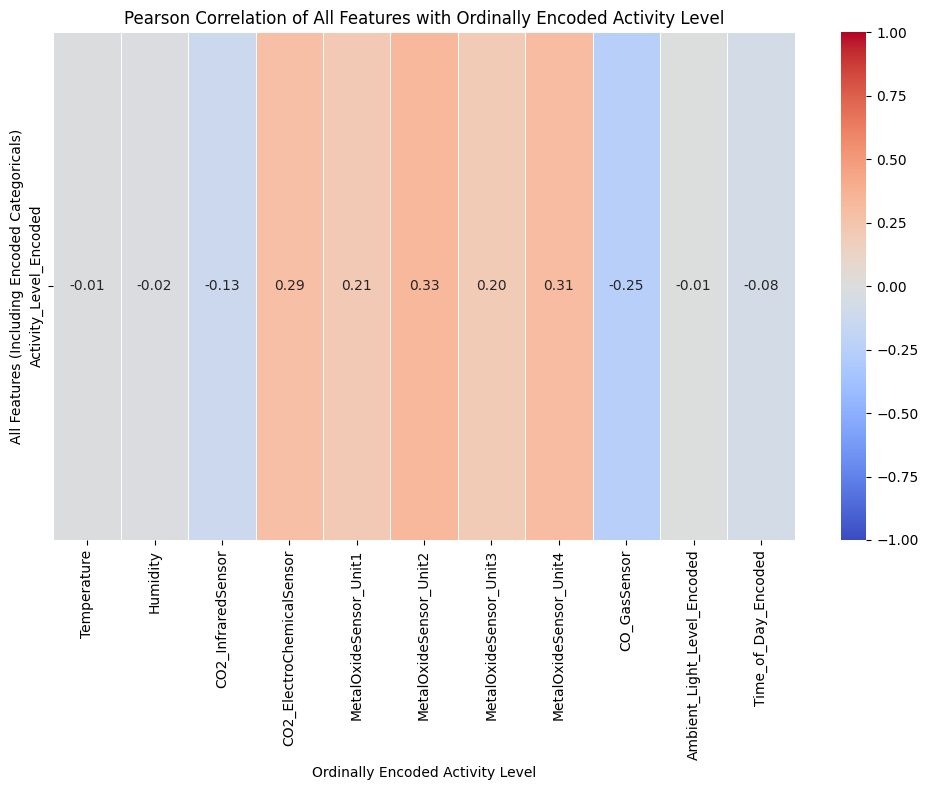

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy to perform transformations
dfv_full_ordinal = df.copy()

# Drop 'Session ID' as it's not relevant for correlation analysis
dfv_full_ordinal = dfv_full_ordinal.drop('Session ID', axis=1)

# --- Standardize and Ordinally Encode 'Activity Level' ---
# Standardize 'Activity Level' categories
dfv_full_ordinal['Activity Level'] = dfv_full_ordinal['Activity Level'].replace({
    'LowActivity': 'Low Activity',
    'ModerateActivity': 'Moderate Activity',
    'Low_Activity': 'Low Activity' # Add this for uniformity if not already done
})
# Ordinally encode 'Activity Level'
activity_mapping = {'Low Activity': 0, 'Moderate Activity': 1, 'High Activity': 2}
dfv_full_ordinal['Activity_Level_Encoded'] = dfv_full_ordinal['Activity Level'].map(activity_mapping)

# --- Standardize and Ordinally Encode 'Ambient Light Level' ---
# Fill NaN values for 'Ambient Light Level' if any, before mapping
dfv_full_ordinal['Ambient Light Level'] = dfv_full_ordinal['Ambient Light Level'].fillna('unknown_light').astype(str)
# Define an ordinal mapping for 'Ambient Light Level'
light_level_mapping = {'very_dim': 0, 'dim': 1, 'moderate': 2, 'bright': 3, 'very_bright': 4, 'unknown_light': -1} # Assign -1 for unknown if needed to preserve missingness
dfv_full_ordinal['Ambient_Light_Level_Encoded'] = dfv_full_ordinal['Ambient Light Level'].map(light_level_mapping)

# --- Standardize and Ordinally Encode 'Time of Day' ---
# Define an ordinal mapping for 'Time of Day'
time_of_day_mapping = {'night': 0, 'morning': 1, 'afternoon': 2, 'evening': 3}
dfv_full_ordinal['Time_of_Day_Encoded'] = dfv_full_ordinal['Time of Day'].map(time_of_day_mapping)

# --- Handle HVAC Operation Mode uniformity, but don't encode for this specific heatmap (unless requested) ---
# Keep HVAC Operation Mode as object type for now, or drop it if it's not going to be numeric for this correlation
dfv_full_ordinal['HVAC Operation Mode'] = dfv_full_ordinal['HVAC Operation Mode'].replace('Ventilation_Only', 'ventilation_only')
# For this specific heatmap, we'll keep it out of the numeric correlation if it's not encoded

# Drop the original categorical columns that have been encoded
dfv_full_ordinal = dfv_full_ordinal.drop(['Activity Level', 'Ambient Light Level', 'Time of Day', 'HVAC Operation Mode'], axis=1)

# Select only numeric columns for Pearson correlation
numeric_df_full_ordinal = dfv_full_ordinal.select_dtypes(include=["number"])

# Calculate the Pearson correlation matrix
corr_matrix_full_ordinal = numeric_df_full_ordinal.corr(method="pearson")

# Extract correlations with the 'Activity_Level_Encoded' column
# Ensure 'Activity_Level_Encoded' is not correlated with itself in the output
activity_level_full_corr = corr_matrix_full_ordinal[['Activity_Level_Encoded']].drop('Activity_Level_Encoded', axis=0)

# Plot the heatmap focused on Activity_Level_Encoded
plt.figure(figsize=(10, 8))
sns.heatmap(
    activity_level_full_corr.T, # Transpose to have features on Y-axis
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation of All Features with Ordinally Encoded Activity Level")
plt.xlabel("Ordinally Encoded Activity Level")
plt.ylabel("All Features (Including Encoded Categoricals)")
plt.tight_layout()
plt.show()

# Data Processing

Dropping Session ID Column

In [ ]:
dfv2 = df.copy().drop('Session ID', axis=1)
# dfv2

NameError: name 'df' is not defined

Reordering Data Table

In [ ]:
# e.g. Original: ['A', 'B', 'C']
dfv3 = dfv2.copy()[['CO_GasSensor',
                    'CO2_InfraredSensor',
                    'CO2_ElectroChemicalSensor',

                    'MetalOxideSensor_Unit1',
                    'MetalOxideSensor_Unit2',
                    'MetalOxideSensor_Unit3',
                    'MetalOxideSensor_Unit4',

                    'Temperature',
                    'Humidity',
                    'Ambient Light Level',
                    'Time of Day',

                    'Activity Level',

                    'HVAC Operation Mode']]

# dfv3

NameError: name 'dfv2' is not defined

Converting Datatype

In [ ]:
# df['CO_GasSensor'] = df['CO_GasSensor'].fillna('')
# 'CO_GasSensor': int, # not possible due to NA values

df = df.astype({'Time of Day': str, 'HVAC Operation Mode': str,
                'Ambient Light Level': str, 'Activity Level': str})

Finding Classes in Column Categories

In [ ]:
tod_classes = df['Time of Day'].unique()
print(tod_classes)

colevel = df['CO_GasSensor'].unique()
print(colevel)

hvacMode_classes = df['HVAC Operation Mode'].unique()
print(hvacMode_classes)

lightLevel_classes = df['Ambient Light Level'].unique()
print(lightLevel_classes)

activitylevel_classes = df['Activity Level'].unique()
print(activitylevel_classes)

['morning' 'afternoon' 'night']
[ 2.  1. nan  0.]
['off' 'ventilation_only' 'eco_mode' 'heating_active' 'Ventilation_Only'
 'maintenance_mode']
['very_dim' 'bright' None 'very_bright' 'moderate']
['Low Activity' 'High Activity' 'LowActivity' 'Moderate Activity']


Data Uniformity

In [ ]:
dfv4 = dfv3.copy()
dfv4['Activity Level'] = dfv3['Activity Level'].copy().replace('LowActivity', 'Low Activity')
dfv4['HVAC Operation Mode'] = dfv3['HVAC Operation Mode'].copy().replace('Ventilation_Only', 'ventilation_only')

hvacMode_classes = dfv4['HVAC Operation Mode'].unique()
print(hvacMode_classes)

activitylevel_classes = dfv4['Activity Level'].unique()
print(activitylevel_classes)

NameError: name 'dfv3' is not defined

Additional Things To-Do for Observation:
- for categorical data (those with non-numeric and label data, what are the list of data they may contain) (DONE)
    - e.g. in HVAC operation mode it has the following:
        - cooling_active
        - eco_mode (referring to slow temperature control)
        - heating_active
        - maintainence_mode
        - off
        - ventilation_mode

Observation (What do you see)
- data shows the detection of co, co2, and metal oxide, light, temp, humidity, work activity level and the use of a HVAC system
- maximum no. of rows is 10,000
- there is missing data in humidity, mextaloxidesensor_unit2, co_gassensor, ambient light level
- missing data have different levels, with humidity having the most missing data and co_gas_sensor being the least

Analysis (What do you understand)
- the aim of the dataset is likely to automate the process of a HVAC system to ensure that when workers are working they are not exposed to high levels of dangerous gases such as co, and temperature levels

Rationale (What to do?)

- Data Table Order & Changes (DONE)
    - Drop Session Id: Id repeats and doesn't seem to have any relations or improtance to other features (DONE)
    - HVAC mode as label for ML: move column to rightmost of the data table
    - have all categorical classes cluster to the right
    - temperature and humidity pushed behind next to ambient light level as they affect each other
    - CO as the First Column: co is most dangerous, as it is invisible and should be the 'main concern'

- Datatype Conversions
    - Time of Day: obj to str
    - HVAC Operation Mode: obj to str
    - Ambient Light Level: obj to str
    - Activity Level: obj to str
    - CO_Sensor: obj to int

- Data Uniformity
    - Change LowActivity to Low Activity to match other Low Activity cells
    - Change Ventilation_Only to ventilation_only to make all the data in the column that is lowercase and matches the other ventilation_only

- Handling Missing Data
    - handle missing co gas data with metal oxide sensor unit and co2 infrared and delectrico chemical sensor (because metal oxide reacts with co and high levels of co2 prevents co from reacting with metal oxide to turn back into co)
    - handle missing ambient light level data using time of day
    - handle humidity by deriving from time of day & temperature
    - handle metaloxidesensor_unit2 missing data using one of the following:
        - using median value from unit 1, 3, 4 (use mean if there is n
        - using cosine similarity of existing unit 2 data)
- apply cos similarity to the sensors, if they have a 95% or more similarity, they should be considered to be aggregated into median value as they are the same
- Feature Engineering
    - tod_classes: Integer Encoding (classes have range of time)
    - hvacMode_classes: (OHE) One-Hot Encoding (distinct)
    - lightlevel_classes: Integer Encoding (classes have a range of intensity)
    - activitylevel_classes: Integer encoding (classes have a range of intensity)

**for rationale, when it is stated as 'median' it assumes the data contains anomalies in the data, if there is not, mean would be better

Placeholder Code (Person's Correlation)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_encoded = pd.get_dummies(
    dfv4, columns=["HVAC Operation Mode"], prefix="HVAC", dtype=int
)

# 3. Select only numeric columns for Pearson correlation
# (This includes your sensors, temp, humidity, and the new OHE HVAC columns)
numeric_df = df_encoded.select_dtypes(include=["number"])

# 4. Calculate the Pearson correlation matrix
corr_matrix = numeric_df.corr(method="pearson")

# 5. Isolate correlations where HVAC modes are the main Y target
hvac_cols = [col for col in corr_matrix.columns if col.startswith("HVAC_")]
hvac_corr = corr_matrix[hvac_cols].drop(
    index=hvac_cols
)  # Drop self-correlation rows

# 6. Plot the heatmap focused on HVAC as the Y-axis
plt.figure(figsize=(10, 8))
sns.heatmap(
    hvac_corr.T,  # Transpose to keep HVAC modes as the Y-axis rows
    annot=True,
    cmap="Coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)

plt.title("Pearson Correlation of Features with HVAC Operation Modes (Y)")
plt.xlabel("Environmental & Gas Sensors")
plt.ylabel("HVAC Operation Modes (Target Y)")
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

Placeholder code (Decision Tree)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 2. Handle missing values (simple fillna to make the tree executable)
# Note: You can replace this with your custom median/cosine similarity logic later
df_clean["CO_GasSensor"] = df_clean["CO_GasSensor"].fillna(
    df_clean["CO_GasSensor"].median()
)

# 3. Separate features (X) and Target (Y)
# We select only the numeric environmental and gas sensors for X
feature_cols = [
    "CO_GasSensor",
    "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor",
    "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4",
    "Temperature",
    "Humidity",
]

X = df_clean[feature_cols]
y = df_clean["HVAC Operation Mode"]

# 4. Initialize and fit the Decision Tree Classifier
# We limit max_depth so it looks at the most dominant, overarching correlations
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X, y)

# 5. Extract Feature Importances
importances = dt_model.feature_importances_

# Create a DataFrame for easy plotting
df_importance = pd.DataFrame(
    {"Feature": feature_cols, "Importance": importances}
).sort_values(by="Importance", ascending=False)

# 6. Plot the feature relationships with HVAC (Y)
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=df_importance,
    palette="viridis",
    hue="Feature",
    legend=False,
)

plt.title("Feature Importance (Non-Linear Correlation) with HVAC Operation Mode")
plt.xlabel("Importance Score (0 to 1)")
plt.ylabel("Sensors & Environmental Features (X)")
plt.tight_layout()
plt.show()

# Display the exact mathematical weights
print(df_importance.to_string(index=False))